In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from tqdm import tqdm
from diffusers import AutoencoderKL
import matplotlib.pyplot as plt
import torch.nn.functional as F
from logregression_trainer import LogisticRegressionModel
from mnist_vae_trainer import SimpleVAE
from vae_visualization import visualize_vae_reconstructions
from vae_visualization import visualize_latent_space
from vae_visualization import visualize_latent_space_interpolation
from vae_visualization import visualize_vae_generation


In [14]:
# Data loaders
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

batch_size = 256  # Smaller batch size due to VAE memory requirements
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Logistic Regression Model

In [15]:
# The model is already trained and i have the weights for it
# If needed to retrain the model,
# call train_logregression() from logregression_trainer
logistic_model = LogisticRegressionModel()
logistic_model.load_state_dict(torch.load('models/logregression.pth'))


<All keys matched successfully>

In [16]:

logistic_model.eval()


LogisticRegressionModel(
  (linear): Linear(in_features=784, out_features=10, bias=True)
)

# VAE for mnist

In [17]:
# Model already trained, 
# If needed to retrain:
# call mnist_vae_trainer(trainloader) from
# mnist_vae_trainer

latent_dim = 32  # Size of the latent space
vae = SimpleVAE(latent_dim=latent_dim).to(device)
vae.load_state_dict(torch.load('models/mnist_vae.pth'))

<All keys matched successfully>

In [18]:
# #freeze the VAE
vae.eval()
for param in vae.parameters():
    param.requires_grad = False

mu and log_var shape are: 96,32

# Visualization of the VAE for mnist

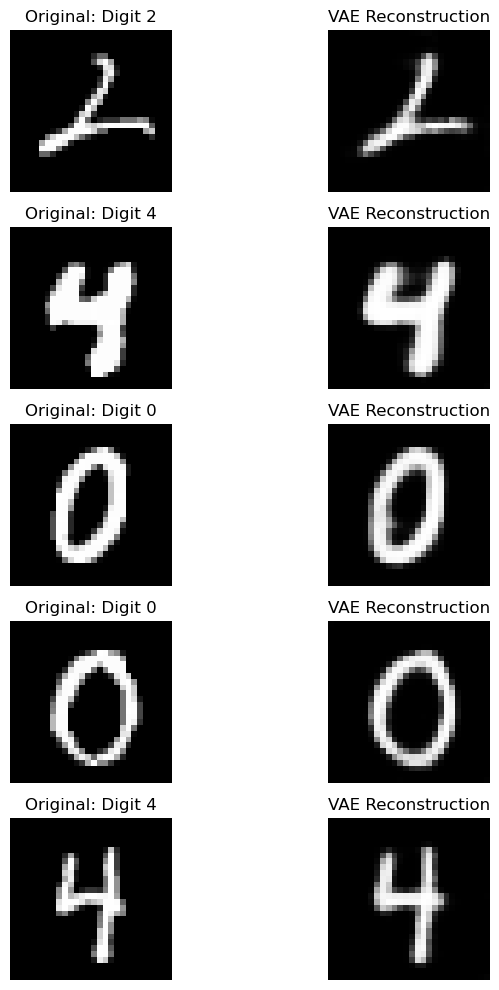

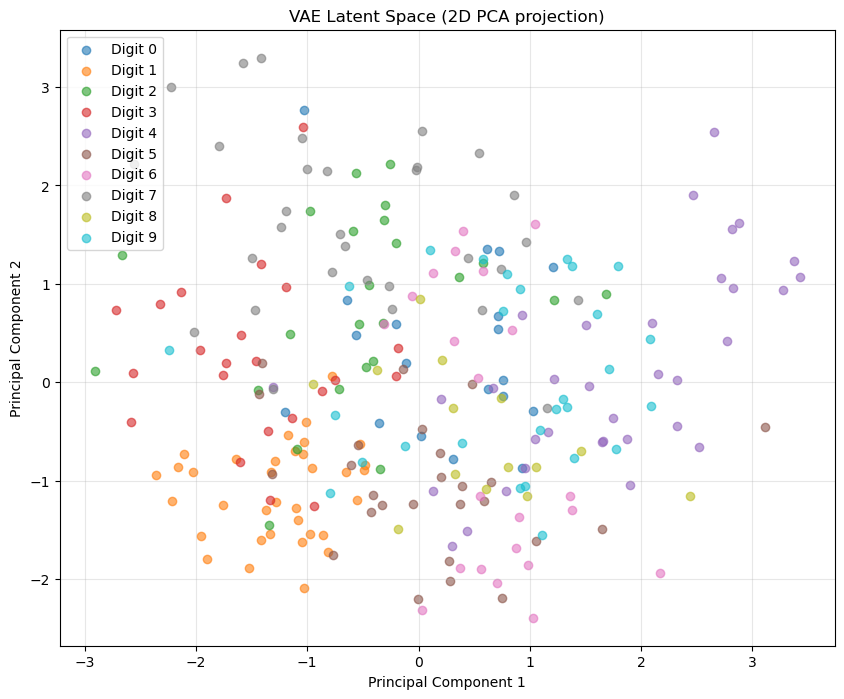

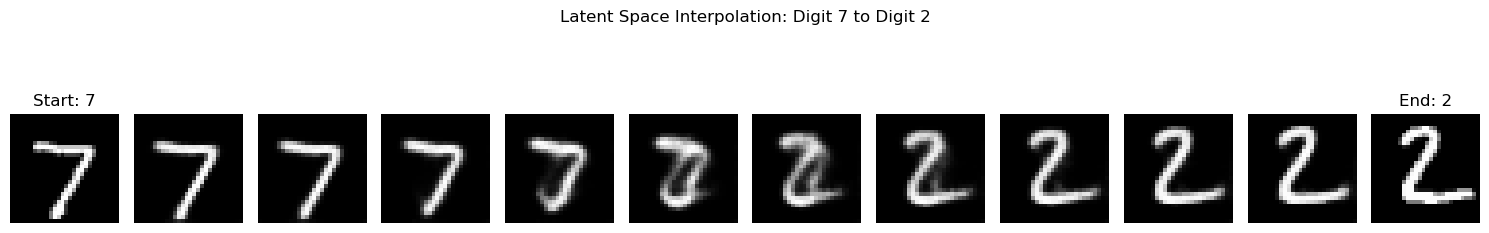

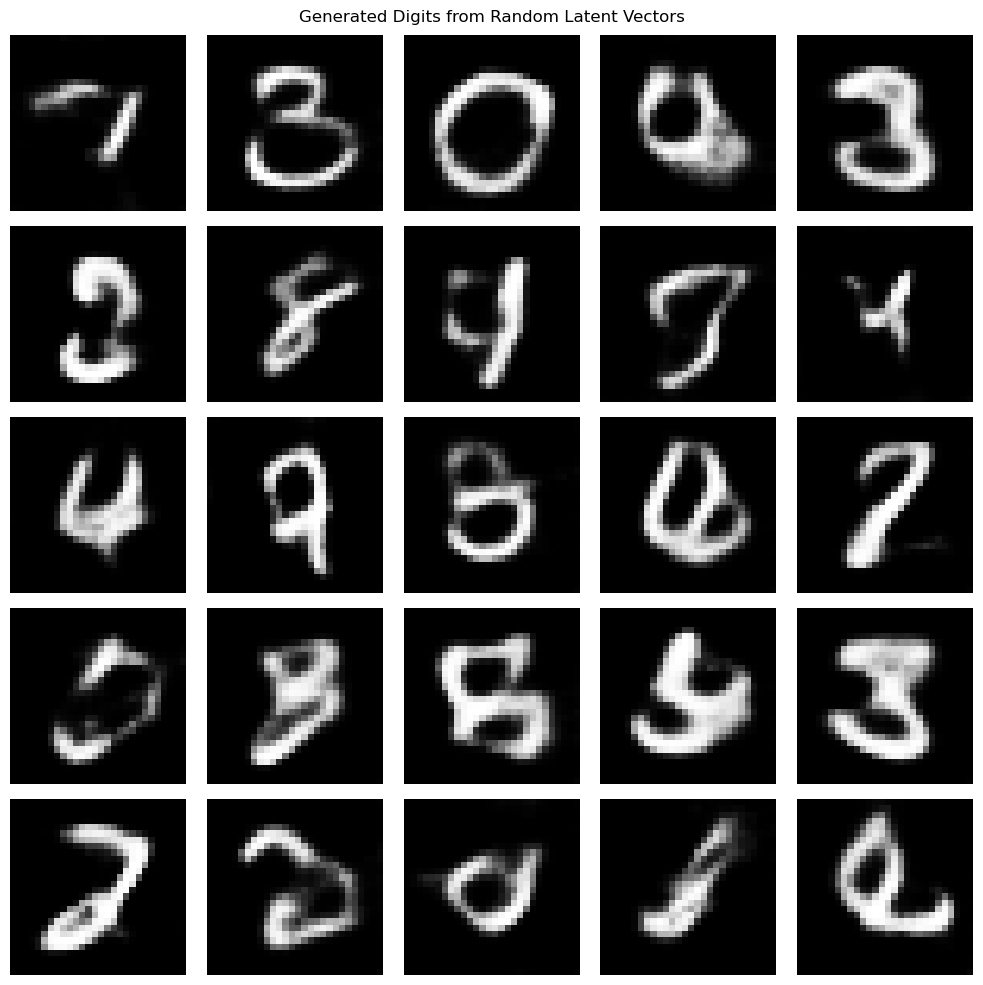

In [19]:
dataiter = iter(testloader)
images, labels = next(dataiter)
images = images.to(device)

visualize_vae_reconstructions(vae, images, labels)
visualize_latent_space(vae, images[:500], labels[:500])
visualize_latent_space_interpolation(vae, images, labels, device)
visualize_vae_generation(vae, device, latent_dim=32)


# Tutor AI

The main nueral network that is being trained is a simple deep NN that has four layers

Then, the combined model has the following architecture:

Original_image ---> Encoder ---> original_mu ---> deepNN ---> mu2 ---> decoder ---> new_image ---> classifier ---> label

In [20]:
# Architecture of Tutor AI

class LatentTransformer(nn.Module):
    def __init__(self, latent_dim=32):
        super(LatentTransformer, self).__init__()
        
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, latent_dim)
        )
    
    def forward(self, x):
        return self.net(x)


class VAEClassifierPipeline(nn.Module):
    def __init__(self, vae, transformer, classifier, alpha=0.5):
        super(VAEClassifierPipeline, self).__init__()
        self.vae = vae
        self.transformer = transformer
        self.classifier = classifier
        
        
        for param in self.vae.parameters():
            param.required_grad = False
        
        for param in self.classifier.parameters():
            param.required_grad = False
    
    def forward(self, x):

        # with torch.no_grad():
        #     mu, log_var = self.vae.encode(x)
        mu, log_var = self.vae.encode(x)
        # Keep original for KL loss
        original_mu = mu.detach()
        original_log_var = log_var.detach()
        
        # We only change the mu,
        # Not interested in z
        transformed_mu = self.transformer(mu)
        
        
        # with torch.no_grad():
        #     decoded = self.vae.decode(transformed_mu)
        
        # with torch.no_grad():
            
        #     logits = self.classifier(decoded)
        decoded = self.vae.decode(transformed_mu)
        logits = self.classifier(decoded)
        return {
            'logits': logits,
            'decoded_image': decoded,
            'original_mu': original_mu,
            'original_log_var': original_log_var,
            'transformed_mu': transformed_mu
        }


def compute_kl_divergence(transformed_mu, original_mu, original_log_var):
    # KL divergence between two Gaussian distributions
    kl_div = 0.5 * torch.sum(((transformed_mu - original_mu).pow(2)) / torch.exp(original_log_var))
    
    return kl_div

If saved, then load

In [21]:
latent_transformer = LatentTransformer(latent_dim=latent_dim).to(device)
# latent_transformer.load_state_dict(torch.load('models/mu_transformer.pth'))
pipeline = VAEClassifierPipeline(vae, latent_transformer, logistic_model).to(device)

training

In [22]:
# vae.eval()
# for param in vae.parameters():
#     param.requires_grad = False

# Hyperparameters for the loss regularization
mse_weight = 0.0005
kl_weight = 0.005
latent_transformer = LatentTransformer(latent_dim=latent_dim).to(device)
pipeline = VAEClassifierPipeline(vae, latent_transformer, logistic_model).to(device)

optimizer = optim.Adam(pipeline.transformer.parameters(), lr=0.0005)
# We need reduction='sum' because we don't want to allow
# Wiggle room for the loss function
# We want to minimize the prob  of other labels 
# While maximizing the prob of true label
classification_criterion = nn.CrossEntropyLoss(reduction='sum')
mse_criterion = nn.MSELoss()

# Training loop for the latent transformer
print("Training the latent space transformer...")
num_epochs = 20
for epoch in range(num_epochs):
    pipeline.transformer.train()  # Only the transformer is trainable
    running_loss = 0.0
    running_class_loss = 0.0
    running_mse_loss = 0.0
    running_kl_loss = 0.0
    for images, labels in tqdm(trainloader, desc=f"Transformer Epoch {epoch+1}/{num_epochs}"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = pipeline(images)
        
        # Calculate the classification loss
        class_loss = classification_criterion(outputs['logits'], labels)
        mse_loss = F.mse_loss(outputs['decoded_image'], images, reduction='sum')
        kl_loss = compute_kl_divergence(outputs['transformed_mu'], outputs['original_mu'], outputs['original_log_var'])
        
        # Combined loss
        
        total_loss = class_loss + mse_weight * mse_loss + kl_weight * kl_loss
        
        total_loss.backward()
        optimizer.step()
        
        running_loss += total_loss.item()
        running_class_loss += class_loss.item()
        running_mse_loss += mse_loss.item()
        running_kl_loss += kl_loss.item()
    
    avg_loss = running_loss / len(trainloader)
    avg_class_loss = running_class_loss / len(trainloader)
    avg_mse_loss = running_mse_loss / len(trainloader)
    avg_kl_loss = running_kl_loss / len(trainloader)
    print(f'Epoch [{epoch+1}/{num_epochs}], '
          f'Total Loss: {avg_loss:.4f}, '
          f'Class Loss: {avg_class_loss:.4f}, '
          f'MSE Loss: {avg_mse_loss:.4f}, '
          f'kl loss: {avg_kl_loss:.4f}')

# Evaluation
pipeline.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in tqdm(testloader, desc="Evaluating"):
        images, labels = images.to(device), labels.to(device)
        outputs = pipeline(images)
        _, predicted = torch.max(outputs['logits'].data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Test Accuracy with Latent Transformation: {100 * correct / total:.2f}%')

# Optional: Evaluate original logistic regression on unmodified images
logistic_model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in tqdm(testloader, desc="Evaluating Original Logistic Model"):
        images, labels = images.to(device), labels.to(device)
        outputs = logistic_model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Original Logistic Regression Accuracy: {100 * correct / total:.2f}%')

# # Optional: Save the trained models

torch.save(latent_transformer.state_dict(), 'models/mu_transformer_change_nograd.pth')

Training the latent space transformer...


Transformer Epoch 1/20: 100%|██████████| 235/235 [00:33<00:00,  7.00it/s]


Epoch [1/20], Total Loss: 311.4827, Class Loss: 154.8459, MSE Loss: 31507.4117, kl loss: 28176.6323


Transformer Epoch 2/20: 100%|██████████| 235/235 [00:33<00:00,  7.09it/s]


Epoch [2/20], Total Loss: 85.1973, Class Loss: 41.4231, MSE Loss: 13507.2926, kl loss: 7404.1041


...

Epoch [20/20], Total Loss: 30.0687, Class Loss: 15.5882, MSE Loss: 7176.2046, kl loss: 2178.4878


Evaluating: 100%|██████████| 40/40 [00:03<00:00, 11.88it/s]


Test Accuracy with Latent Transformation: 98.06%


Evaluating Original Logistic Model: 100%|██████████| 40/40 [00:01<00:00, 27.38it/s]

Original Logistic Regression Accuracy: 91.81%


In [25]:


def denormalize(tensor):
    """Convert a tensor image back to a displayable format."""
    return tensor * 0.5 + 0.5  # Assuming images were normalized to [-1,1]

# Switch models to evaluation mode
pipeline.eval()
logistic_model.eval()

# Storage for misclassified then corrected examples
corrected_samples = []
corrected_labels = []
data_dist = []
with torch.no_grad():
    for images, labels in tqdm(testloader, desc="Identifying Corrected Samples"):
        images, labels = images.to(device), labels.to(device)
        
        # Get original logistic regression predictions
        orig_outputs = logistic_model(images)
        _, orig_preds = torch.max(orig_outputs.data, 1)
        
        # Get pipeline predictions
        outputs = pipeline(images)
        _, new_preds = torch.max(outputs['logits'].data, 1)
        
        # Identify misclassified by original model but corrected by new model
        print(orig_preds)
        mask = (orig_preds != labels) & (new_preds == labels)
        if mask.sum() > 0:
            for i in range(mask.sum()):
                corrected_samples.append((images[mask][i], outputs['decoded_image'][mask][i]))
                corrected_labels.append({"orig_label":orig_preds[mask][i], "new_label": new_preds[mask][i]})
                
                data_dist.append({"orig_label":orig_outputs.data.data[mask][i], "new_label": outputs['logits'].data[mask][i]})
                print(f'found an image')
        
        # Stop early if we found enough samples
        if len(corrected_samples) >= 20:
            break


plt.show()


Identifying Corrected Samples:   2%|▎         | 1/40 [00:00<00:09,  3.94it/s]

tensor([7, 2, 1, 0, 4, 1, 4, 9, 6, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4, 9, 6, 6, 5,
        4, 0, 7, 4, 0, 1, 3, 1, 3, 6, 7, 2, 7, 1, 2, 1, 1, 7, 4, 2, 3, 5, 1, 2,
        4, 4, 6, 3, 5, 5, 6, 0, 4, 1, 9, 5, 7, 8, 9, 2, 7, 4, 7, 4, 3, 0, 7, 0,
        2, 9, 1, 7, 3, 7, 9, 7, 7, 6, 2, 7, 8, 4, 7, 3, 6, 1, 3, 6, 4, 3, 1, 4,
        1, 7, 6, 9, 6, 0, 5, 4, 9, 9, 2, 1, 9, 4, 8, 7, 3, 9, 7, 4, 4, 4, 9, 2,
        5, 4, 7, 6, 4, 9, 0, 5, 8, 5, 6, 6, 5, 7, 8, 1, 0, 1, 6, 4, 6, 7, 3, 1,
        7, 1, 8, 2, 0, 9, 9, 9, 5, 5, 1, 5, 6, 0, 3, 4, 4, 6, 5, 4, 6, 5, 4, 5,
        1, 4, 4, 7, 2, 3, 2, 7, 1, 8, 1, 8, 1, 8, 5, 0, 8, 9, 2, 5, 0, 1, 1, 1,
        0, 3, 0, 5, 1, 6, 4, 2, 3, 6, 1, 1, 1, 3, 9, 5, 2, 9, 4, 7, 9, 3, 9, 0,
        3, 5, 5, 5, 7, 2, 2, 7, 1, 2, 8, 4, 1, 7, 3, 3, 8, 7, 7, 9, 2, 2, 4, 1,
        5, 8, 8, 7, 2, 5, 0, 2, 4, 2, 4, 1, 9, 5, 7, 7])
found an image
found an image
found an image
found an image
found an image
found an image
found an image
found an image
found an image
found an

[{'orig_label': tensor(6), 'new_label': tensor(4)}, {'orig_label': tensor(2), 'new_label': tensor(3)}, {'orig_label': tensor(7), 'new_label': tensor(6)}, {'orig_label': tensor(7), 'new_label': tensor(2)}, {'orig_label': tensor(4), 'new_label': tensor(9)}, {'orig_label': tensor(4), 'new_label': tensor(7)}, {'orig_label': tensor(9), 'new_label': tensor(2)}, {'orig_label': tensor(3), 'new_label': tensor(9)}, {'orig_label': tensor(5), 'new_label': tensor(3)}, {'orig_label': tensor(7), 'new_label': tensor(5)}, {'orig_label': tensor(5), 'new_label': tensor(6)}, {'orig_label': tensor(7), 'new_label': tensor(8)}, {'orig_label': tensor(8), 'new_label': tensor(9)}, {'orig_label': tensor(5), 'new_label': tensor(3)}, {'orig_label': tensor(4), 'new_label': tensor(8)}, {'orig_label': tensor(6), 'new_label': tensor(4)}, {'orig_label': tensor(9), 'new_label': tensor(7)}, {'orig_label': tensor(5), 'new_label': tensor(3)}, {'orig_label': tensor(3), 'new_label': tensor(2)}, {'orig_label': tensor(7), 'new

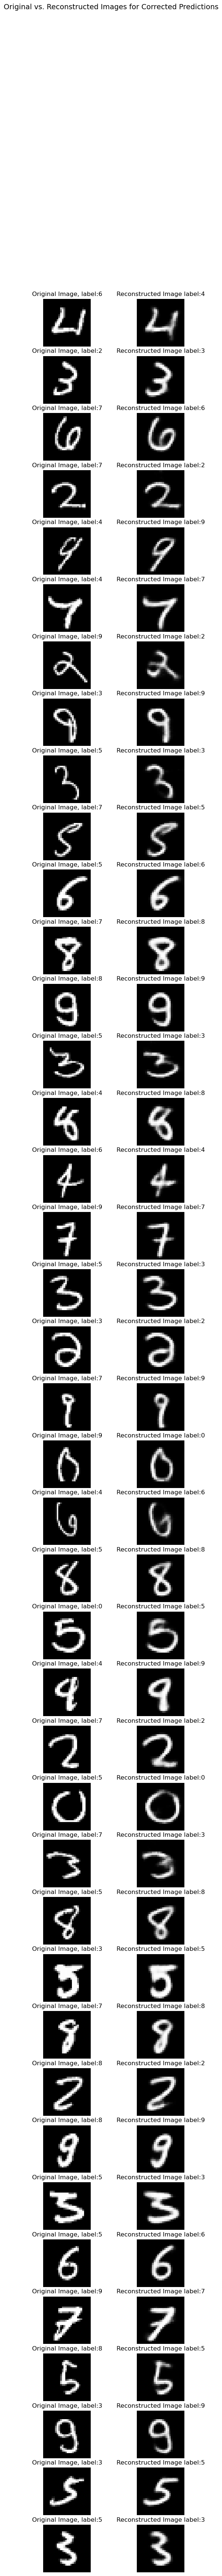

In [27]:
# Plot the first few examples
fig, axes = plt.subplots(len(corrected_samples), 2, figsize=(6, len(corrected_samples) * 2))
fig.suptitle("Original vs. Reconstructed Images for Corrected Predictions", fontsize=14)
print(corrected_labels)
for i, (orig_img, decoded_img) in enumerate(corrected_samples):
    orig_img = denormalize(orig_img.cpu().permute(1, 2, 0))
    decoded_img = denormalize(decoded_img.cpu().permute(1, 2, 0))
    
    axes[i, 0].imshow(orig_img, cmap='gray')
    axes[i, 0].set_title(f"Original Image, label:{corrected_labels[i]['orig_label']}")
    axes[i, 0].axis("off")
    
    axes[i, 1].imshow(decoded_img, cmap='gray')
    axes[i, 1].set_title(f"Reconstructed Image label:{corrected_labels[i]['new_label']}")
    axes[i, 1].axis("off")
    
plt.savefig('figs/combinedmodel_compare.png')
plt.show()

[{'orig_label': tensor(6), 'new_label': tensor(4)}, {'orig_label': tensor(2), 'new_label': tensor(3)}, {'orig_label': tensor(7), 'new_label': tensor(6)}, {'orig_label': tensor(7), 'new_label': tensor(2)}, {'orig_label': tensor(4), 'new_label': tensor(9)}, {'orig_label': tensor(4), 'new_label': tensor(7)}, {'orig_label': tensor(9), 'new_label': tensor(2)}, {'orig_label': tensor(3), 'new_label': tensor(9)}, {'orig_label': tensor(5), 'new_label': tensor(3)}, {'orig_label': tensor(7), 'new_label': tensor(5)}, {'orig_label': tensor(5), 'new_label': tensor(6)}, {'orig_label': tensor(7), 'new_label': tensor(8)}, {'orig_label': tensor(8), 'new_label': tensor(9)}, {'orig_label': tensor(5), 'new_label': tensor(3)}, {'orig_label': tensor(4), 'new_label': tensor(8)}, {'orig_label': tensor(6), 'new_label': tensor(4)}, {'orig_label': tensor(9), 'new_label': tensor(7)}, {'orig_label': tensor(5), 'new_label': tensor(3)}, {'orig_label': tensor(3), 'new_label': tensor(2)}, {'orig_label': tensor(7), 'new

/tmp/ipykernel_11478/4016417143.py:8: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig= plt.figure(figsize=(3,3))



 

tensor(7)

 

tensor(8)

 

tensor(5)

 

tensor(4)

 

tensor(6)

 

tensor(9)

 

tensor(5)

 

tensor(3)

 

tensor(7)

 

tensor(9)

 

tensor(4)

 

tensor(5)

 

tensor(0)

 

tensor(4)

 

tensor(7)

 

tensor(5)

 

tensor(7)

 

tensor(5)

 

tensor(3)

 

tensor(7)

 

tensor(8)

 

tensor(8)

 

tensor(5)

 

tensor(5)

 

tensor(9)

 

tensor(8)

 

tensor(3)

 

tensor(3)

 

tensor(5)

 



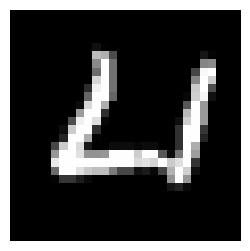

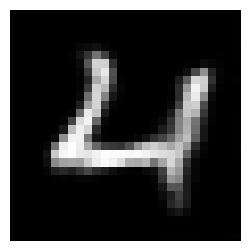

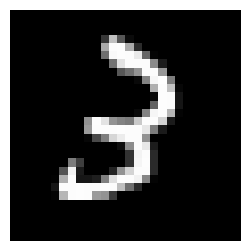

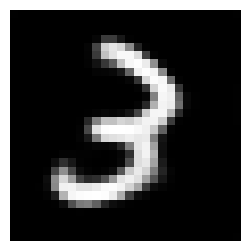

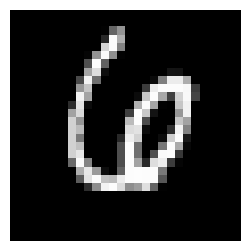

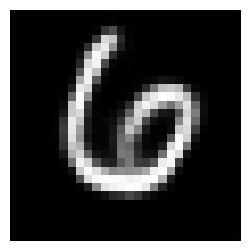

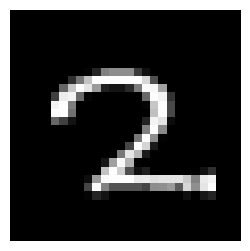

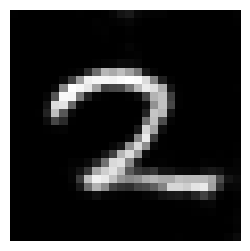

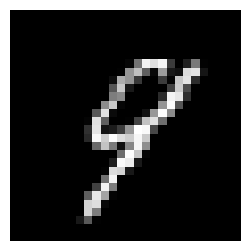

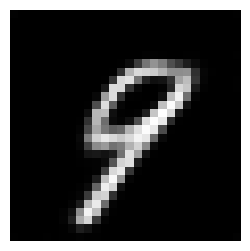

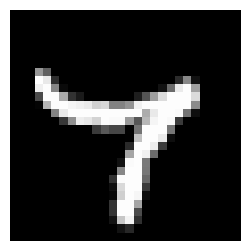

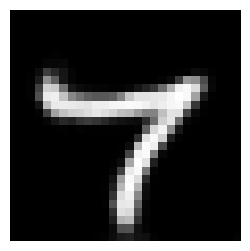

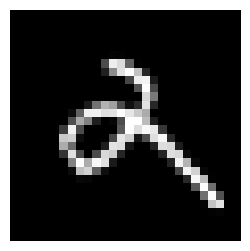

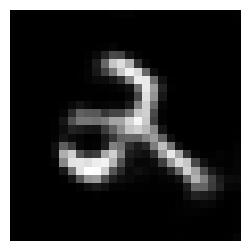

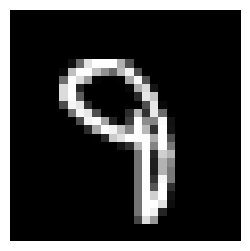

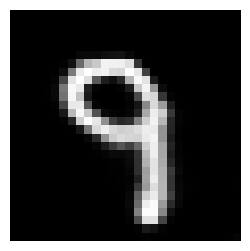

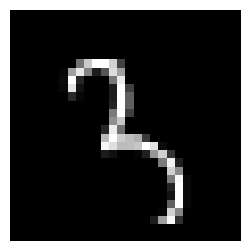

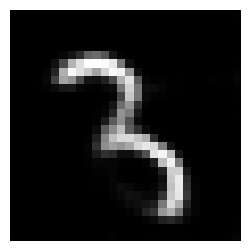

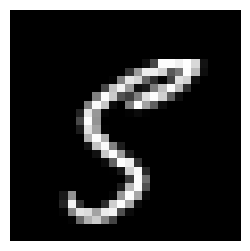

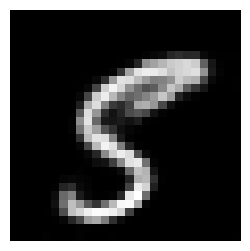

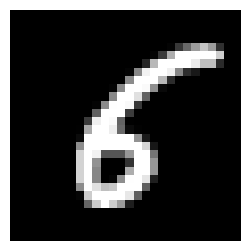

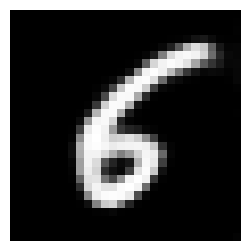

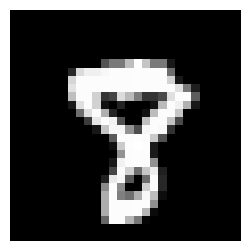

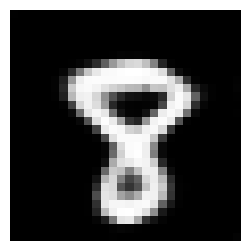

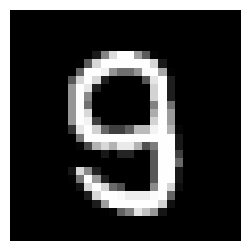

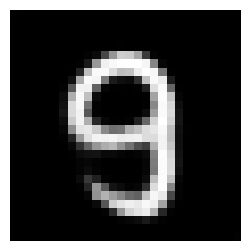

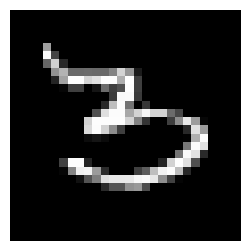

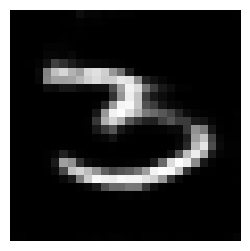

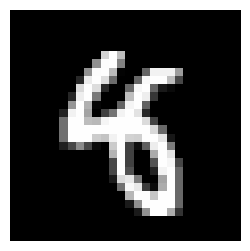

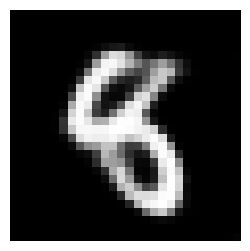

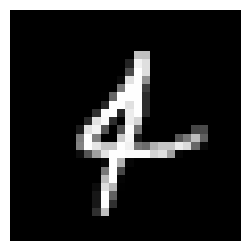

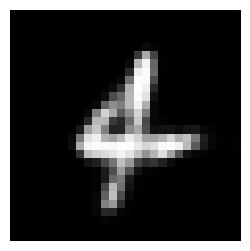

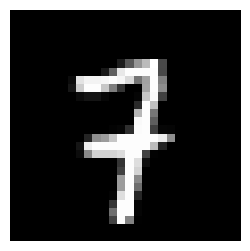

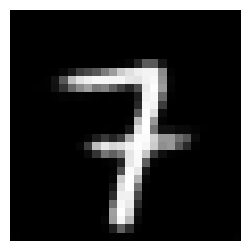

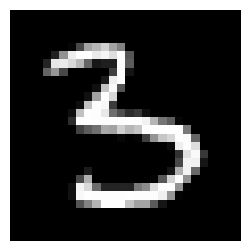

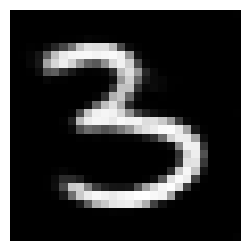

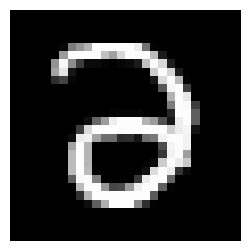

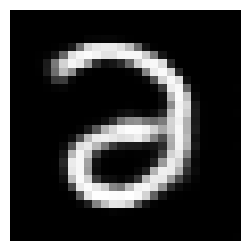

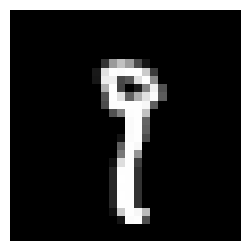

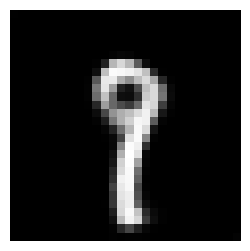

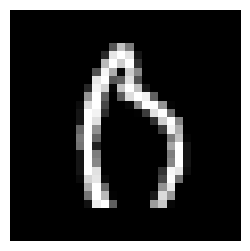

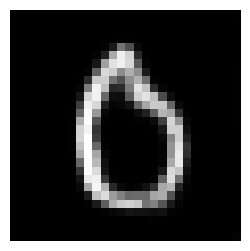

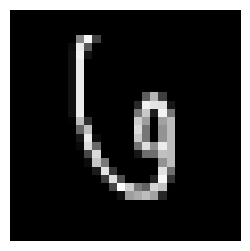

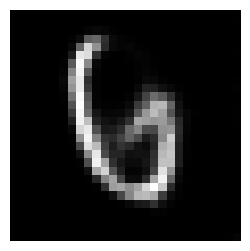

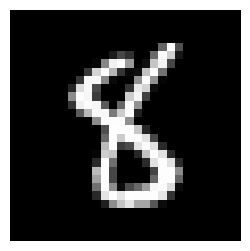

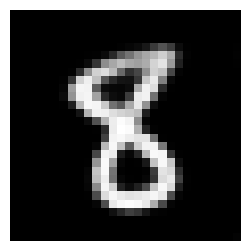

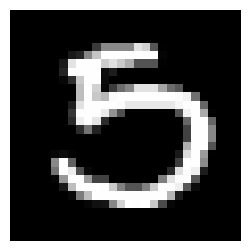

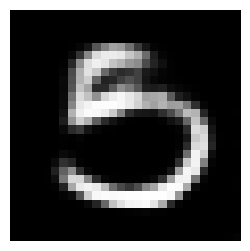

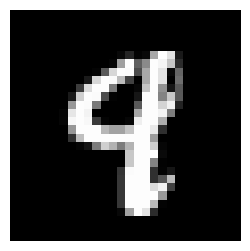

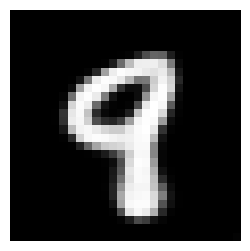

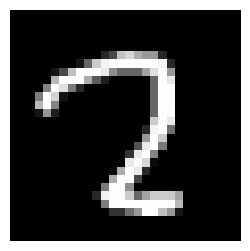

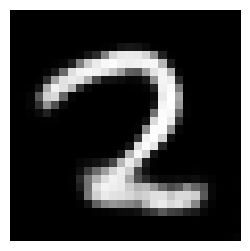

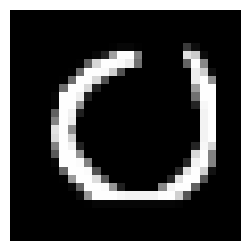

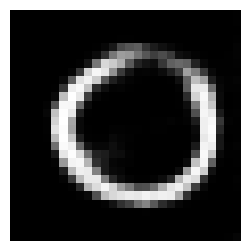

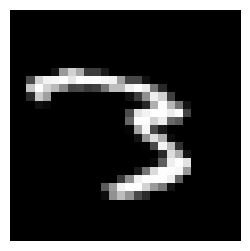

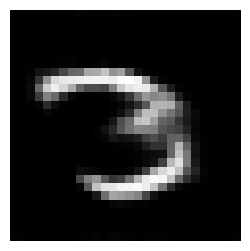

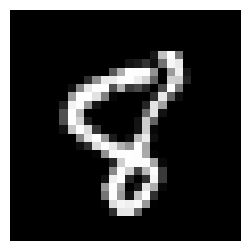

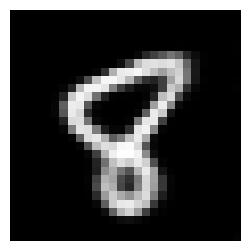

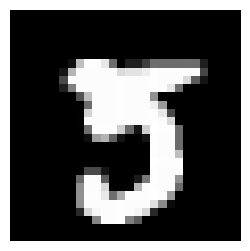

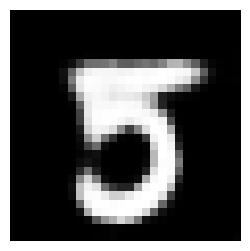

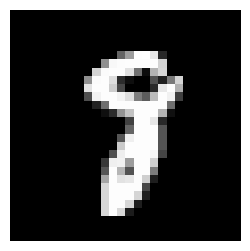

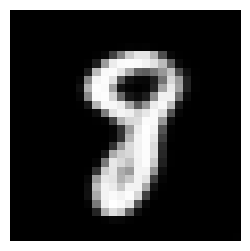

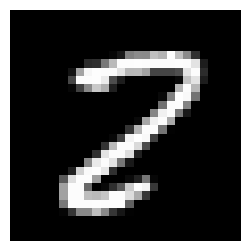

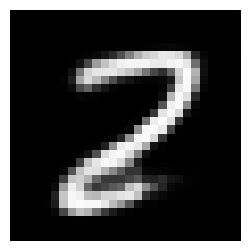

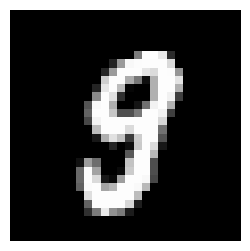

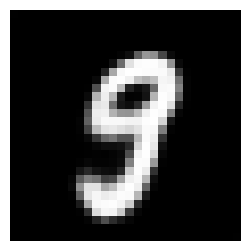

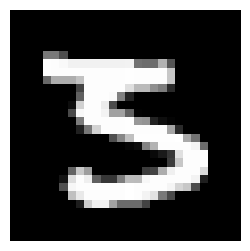

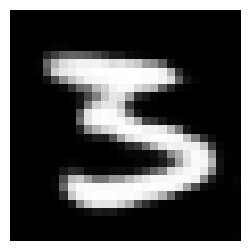

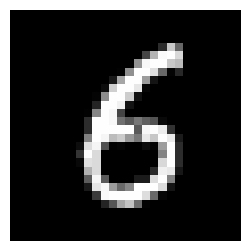

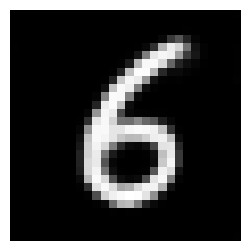

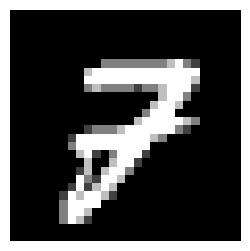

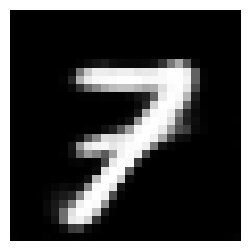

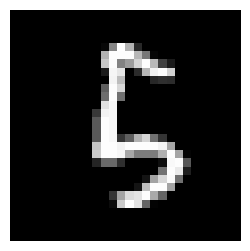

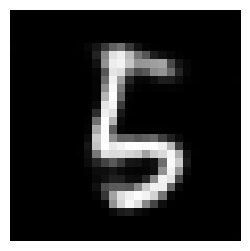

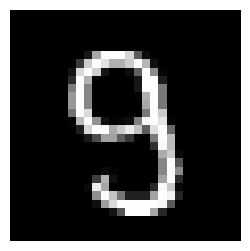

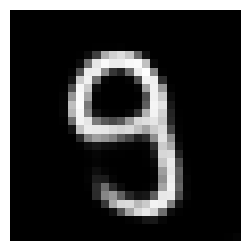

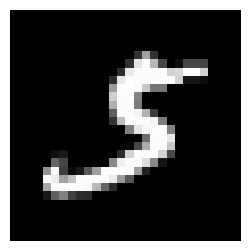

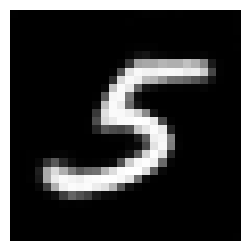

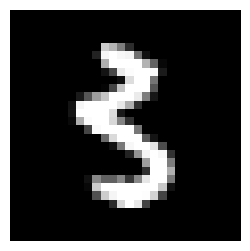

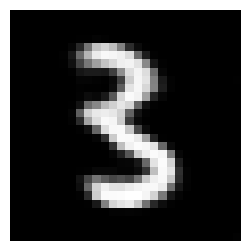

In [29]:
# Plot the first few examples

# fig.suptitle("Original vs. Reconstructed Images for Corrected Predictions", fontsize=14)
print(corrected_labels)
for i, (orig_img, decoded_img) in enumerate(corrected_samples):
    orig_img = denormalize(orig_img.cpu().permute(1, 2, 0))
    decoded_img = denormalize(decoded_img.cpu().permute(1, 2, 0))
    fig= plt.figure(figsize=(3,3))
    plt.imshow(orig_img, cmap='gray')
    print(corrected_labels[i]['orig_label'])
    plt.axis('off')
    plt.savefig(f"figs/orig_image__{i}_l{corrected_labels[i]['orig_label']}.pdf", bbox_inches="tight")
    #plt.set_title(f"Original Image, label:{corrected_labels[i]['orig_label']}")
    #axes[i, 0].axis("off")
    fig= plt.figure(figsize=(3,3))
    plt.imshow(decoded_img, cmap='gray')
    plt.axis("off")
    plt.savefig(f"figs/reconstructred_image_{i}_l{corrected_labels[i]['new_label']}.pdf", bbox_inches="tight")
    print('\n \n')
    # axes[i, 1].set_title(f"Reconstructed Image label:{corrected_labels[i]['new_label']}")
    # axes[i, 1].axis("off")
    
plt.savefig('figs/combinedmodel_compare.png')
plt.show()

In [21]:
# Code to find and visualize examples where the transformation improved classification
def find_improved_examples(original_model, combined_model, test_loader, num_examples=10):
    original_model.eval()
    combined_model.eval()
    
    improved_images = []
    true_labels = []
    original_preds = []
    improved_preds = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            
            # Get predictions from original model
            original_outputs = original_model(images)
            _, original_predictions = torch.max(original_outputs, 1)
            
            # Get predictions from combined model
            combined_outputs = combined_model(images)
            #combined_outputs, transformed_images, _, _, _ = combined_model(images)
            _, combined_predictions = torch.max(combined_outputs['logits'], 1)
            
            # Find examples where original model was wrong but combined model is correct
            improved_mask = (original_predictions != labels) & (combined_predictions == labels)
            
            if improved_mask.sum() > 0:
                for i in range(improved_mask.sum()):
                    
                    improved_images.append((images[improved_mask][i], combined_outputs['decoded_image'][improved_mask][i]))
                    true_labels.append(labels[improved_mask][i])
                    original_preds.append(original_predictions[improved_mask][i])
                    improved_preds.append(combined_predictions[improved_mask][i])
            
            # Check if we have enough examples
            total_found = len(improved_preds)
            if total_found >= 8:
                break
    
    # # Combine the first num_examples
    # selected_images = []
    # selected_transformed = []
    # selected_labels = []
    # selected_original_preds = []
    # selected_improved_preds = []
    
    # examples_needed = num_examples
    # for i in range(len(true_labels)):
    #     batch_size = len(true_labels[i])
    #     take = min(examples_needed, batch_size)
        
    #     selected_images.append(improved_images[i][0][:take])
    #     selected_transformed.append(improved_images[i][1][:take])
    #     selected_labels.append(true_labels[i][:take])
    #     selected_original_preds.append(original_preds[i][:take])
    #     selected_improved_preds.append(improved_preds[i][:take])
        
    #     examples_needed -= take
    #     if examples_needed <= 0:
    #         break
    
    # Concatenate all selected examples
    if selected_images:
        selected_images = torch.cat(improved_images[])
        selected_transformed = torch.cat(selected_transformed)
        selected_labels = torch.cat(selected_labels)
        selected_original_preds = torch.cat(selected_original_preds)
        selected_improved_preds = torch.cat(selected_improved_preds)
        
        return selected_images, selected_transformed, selected_labels, selected_original_preds, selected_improved_preds
    else:
        return None

# Find examples where transformation improved classification
print("Finding examples where the transformation network improved classification...")
improved_data = find_improved_examples(logistic_model, pipeline, testloader, num_examples=10)

if improved_data:
    images, transformed_images, true_labels, original_preds, improved_preds = improved_data
    
    # Denormalize images for visualization (from [-1,1] to [0,1])
    images_viz = (images * 0.5) + 0.5
    transformed_viz = (transformed_images * 0.5) + 0.5
    
    # Visualize the improved examples
    plt.figure(figsize=(20, 15))
    
    for i in range(min(10, images.size(0))):
        # Original image with incorrect prediction
        plt.subplot(3, 10, i + 1)
        plt.imshow(images_viz[i].cpu().squeeze().numpy(), cmap='gray')
        plt.title(f"Original Image")
        plt.axis('off')
        
        # Original prediction (incorrect)
        plt.subplot(3, 10, i + 11)
        plt.imshow(images_viz[i].cpu().squeeze().numpy(), cmap='gray')
        plt.title(f"Original Pred: {original_preds[i].item()}")
        plt.xlabel(f"True Label: {true_labels[i].item()}")
        plt.axis('off')
        
        # Transformed image with correct prediction
        plt.subplot(3, 10, i + 21)
        plt.imshow(transformed_viz[i].cpu().squeeze().numpy(), cmap='gray')
        plt.title(f"Transformed")
        plt.xlabel(f"Pred: {improved_preds[i].item()} ✓")
        plt.axis('off')
    
    plt.suptitle("Examples where transformation improved classification", fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()
    
    # Additional detailed 2x5 grid visualization
    plt.figure(figsize=(15, 6))
    for i in range(min(10, images.size(0))):
        plt.subplot(2, 5, i + 1)
        
        # Create a side-by-side comparison
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
        
        # Original image
        ax1.imshow(images_viz[i].cpu().squeeze().numpy(), cmap='gray')
        ax1.set_title(f"Original\nPred: {original_preds[i].item()} ✗")
        ax1.axis('off')
        
        # Transformed image
        ax2.imshow(transformed_viz[i].cpu().squeeze().numpy(), cmap='gray')
        ax2.set_title(f"Transformed\nPred: {improved_preds[i].item()} ✓")
        ax2.axis('off')
        
        plt.suptitle(f"True Label: {true_labels[i].item()}")
        plt.tight_layout()
        plt.show()
else:
    print("Could not find enough examples where transformation improved classification.")
    print("This could mean either the original model is already very accurate or the transformation did not help significantly.")
    print("Try running the training for more epochs or adjusting the transformation network architecture.")

Finding examples where the transformation network improved classification...


UnboundLocalError: local variable 'selected_images' referenced before assignment